In [1]:
%matplotlib widget
from epdfsuite import SAEDProcessor, extract_epdf

## I.Create Sample Instance

In [2]:
datapath = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_II/'
sample_diff = datapath + "APH135b/Metro/diff/80X_Metro_200kV_1386.dm4" 
poni_file = datapath + 'calib_metro.poni'
mask = datapath + 'mask_test.edf' # very large mask, for test prupose and to simulate the presence of beamstop
mtf_file = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf/metro_slanted.mtf'
sample = SAEDProcessor(sample_diff,
                     poni_file=poni_file,
                     mask=mask,
                     mtf_file= mtf_file,
                     # filter = 'rl',
                     # n_iterations = 50, # silent call to deconvolution parameters, which can be adjusted as needed
                     verbose=True)

Loaded file: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_II/APH135b/Metro/diff/80X_Metro_200kV_1386.dm4
Sample information:
  binning: 1
  description: Gatan 80X Metro direct electron detector
  image_height: 2048
  image_width: 2048
  pixel_size: 5
  camera_type: Gatan 80X Metro
  camera_title: 80X_Metro_200kV_1386
  wavelength: 0.025079340450548007
  exposure_time: 128.00005974713713
[RL] Converged at iteration 22 (Δrel=9.87e-03 < 0.01)


***Plot to estimate centre***

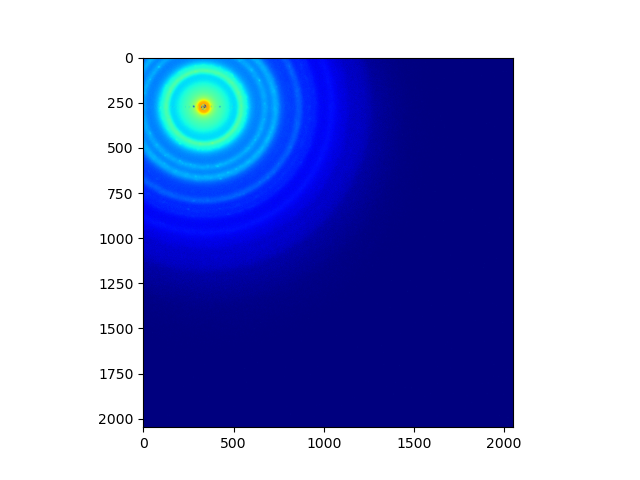

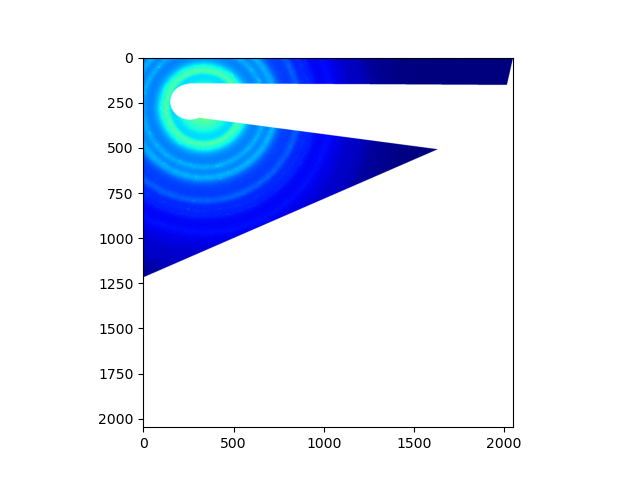

In [3]:
sample.plot(display_mask=False)
sample.plot(display_mask=True) # default value is False, so mask is not shown

In [4]:
sample.initial_center = [350,313]

**Various methods illustrated for demo**

- plot_recalibrated_image: shows how the center is recomputed based on the initial center given by the user
- integrate: shows the radial profile in reciprocal space unit

Using user-provided initial center: (350.0, 313.0)
External mask provided
Masked pixels: 3109955 / 4194304 (74.1%)


/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/recalibration.py:177: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = morphology.remove_small_objects(binary, min_size=min_size)


Convergence reached after 62 iterations (displacement: 0.94 px)


/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/recalibration.py:286: UserWarning: The following kwargs were not used by contour: 'label'
  ax3.contour(binary, levels=[0.5], colors='yellow', linewidths=1,


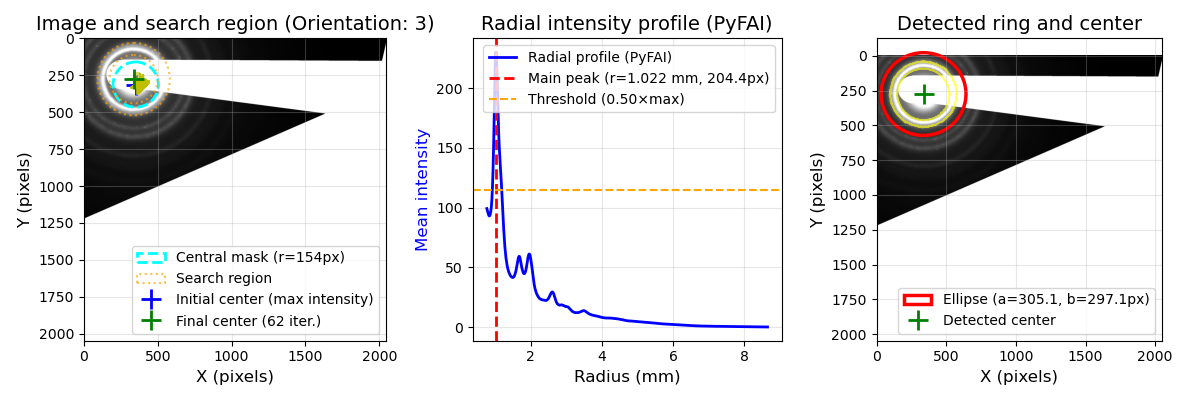

In [5]:
sample.plot_recalibrated_image()

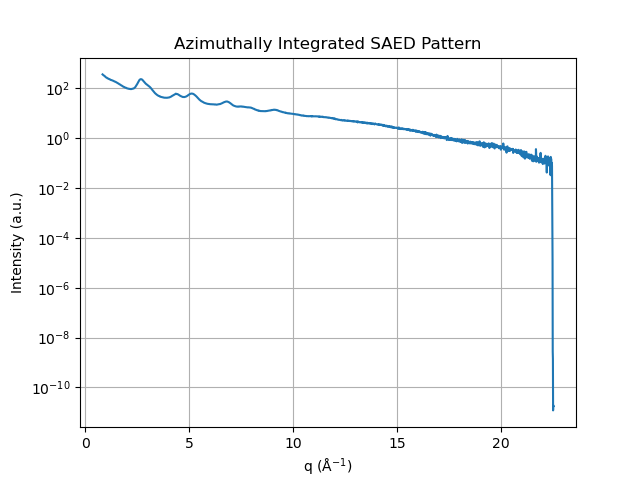

In [6]:
q,i=sample.integrate(plot=True)

## II.Create Ref instance

[RL] Converged at iteration 22 (Δrel=9.84e-03 < 0.01)


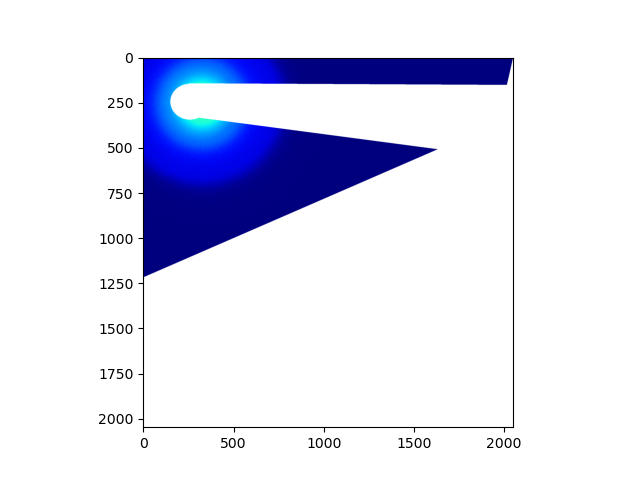

In [7]:
ref_diff = datapath+ 'ref/80X_Metro_200kV_1383_Cfilm.dm4' # amorphous C grid diffraction data

ref = SAEDProcessor(ref_diff,
                     poni_file=poni_file,
                     mask=mask,
                     mtf_file= mtf_file,
                     verbose=False)
ref.plot(display_mask=True)

In [8]:
ref.initial_center = [330,232]

Using user-provided initial center: (330.0, 232.0)
External mask provided
Masked pixels: 3109955 / 4194304 (74.1%)
Convergence reached after 3 iterations (displacement: 0.43 px)


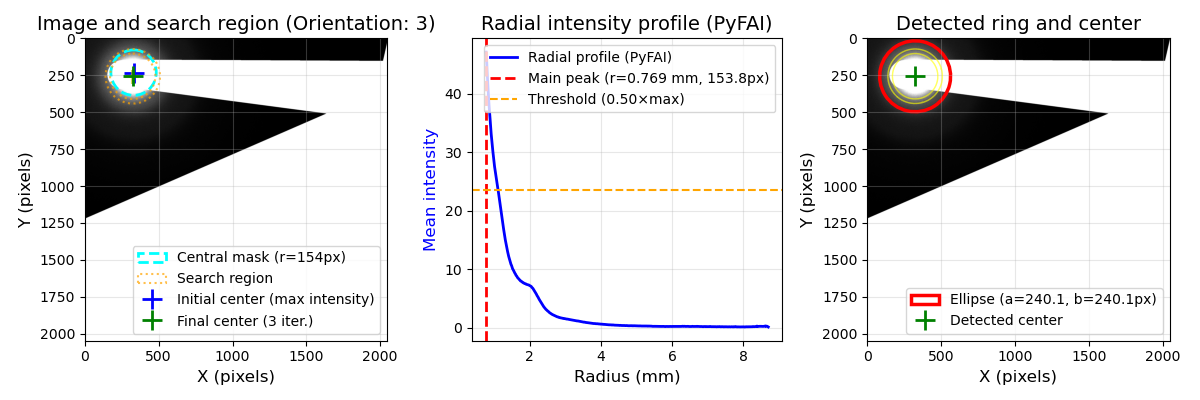

In [9]:
ref.plot_recalibrated_image()

## III. Extract ePDF using standalone function ***extract_epdf***

This function needs the following args:
- sample SAEDProcessor instance
- ref SAEDProcessor instance
- composition
- rmin, rmax, rstep: parameters to define r grid on which the PDF is extracted
- interactive: bool parameter for interactive PDF extraction 

        interactive = True: allows the user to determine manually bgscale, qmin, qmax, qmaxinst and rpoly parameters for PDF extraction

        interactive = False: bgscale, qmin, qmax, qmaxinst and rpoly parameters for PDF extraction can be passed as args to extract_epdf method.

In [10]:
results = extract_epdf(
    sample, 
    ref,
    composition = 'Au',
    rmin=0.0,
    rmax=50.0,
    rstep=0.01,
    interactive = True)

Slide cursors to ajdust parameters values. Click "Save" to export results.


PDF saved to ./pdf_results.gr
